<code>What is sampling?</code>

Sampling is the process of selecting a statistical subset (a sample) from larger group (the population) to estimate characterstics of the entire dataset. Because analyzing an entire population is often computationally impossible or economically unfeasible, we rely on sample.

<code>What is resampling?</code>

Resampling is the process of repeatedly drawing samples from your existing, original sample to assess the variability of a statistics or model.

<code>The difference:</code>

- Sampling: Drawing from the real world population-> Creating the sample(Focus: Data collection).
- Resampling: Drawing from the sample -> creating sub-samples (Focus: Model evaluation/validation).

- Population(N)
- Sample(n)
- Features(X)
- Distribution
- Bias
- Variance
- Generalization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


np.random.seed(42)

population_size = 10000
ages = np.random.normal(loc=45,scale=15,size=population_size)
incomes = 30000 + (ages * 1000) + np.random.normal(0,15000,size=population_size)

p_df = pd.DataFrame({"Age":ages,"Income":incomes})

In [2]:
p_df.shape

(10000, 2)

<code>Types of sampling</code>

- Simple Random Sampling
- Systematic Sampling
- Stratified Sampling

<code>Random Sampling</code>

In [3]:
sample_df = p_df.sample(n=200,random_state=42)

In [4]:
sample_df.shape

(200, 2)

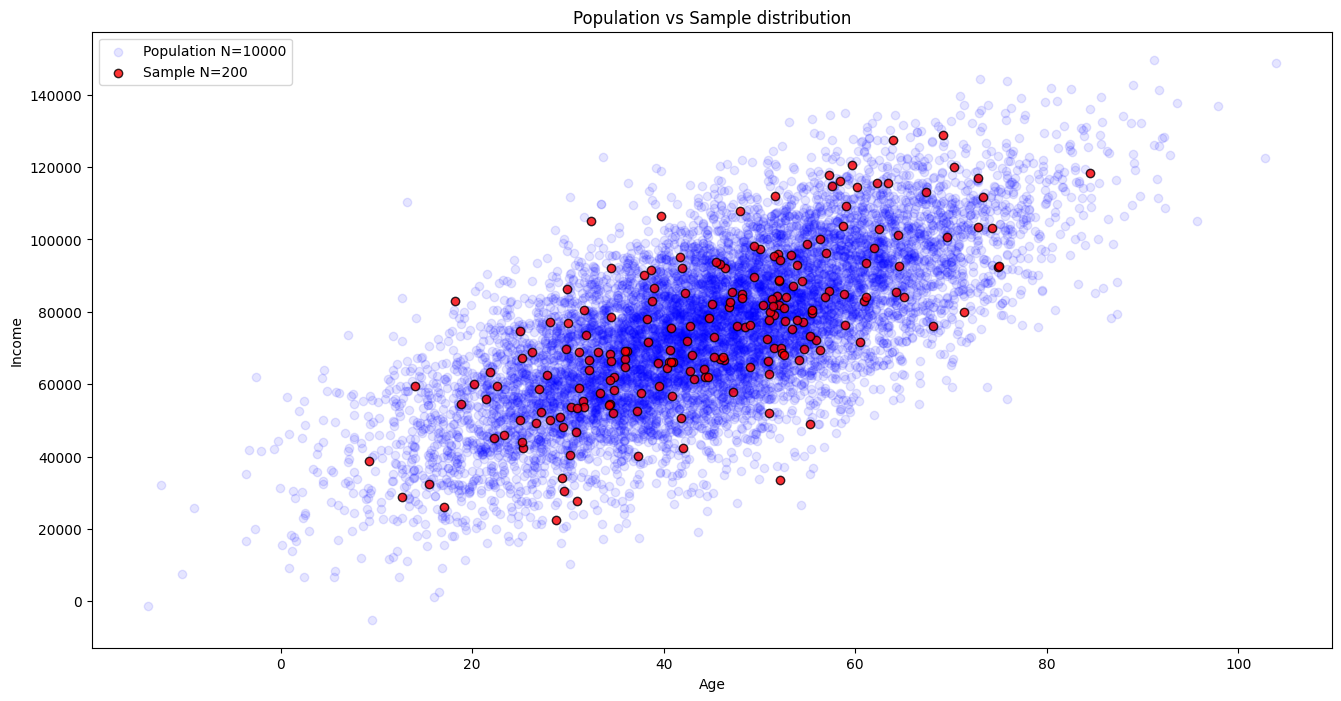

In [5]:
plt.figure(figsize=(16,8))
plt.scatter(p_df['Age'],p_df['Income'],alpha=0.1,label='Population N=10000',color='blue')
plt.scatter(sample_df['Age'],sample_df['Income'],alpha=0.8,label='Sample N=200',color='red',edgecolor='black')
plt.title("Population vs Sample distribution")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.show()

<code>Systematic Sampling</code>

In [6]:
production_line = np.arange(0,100)
k = 10

start=2

systematic_sample = production_line[start::k]
print(systematic_sample)

[ 2 12 22 32 42 52 62 72 82 92]


<code>Stratified Sampling</code>

In [7]:
health_status = ['Healthy']*900 + ['Sick']*100

df = pd.DataFrame({'ParentID':np.arange(1,1001),'Status':health_status})
df

,ParentID,Status
0,1,Healthy
1,2,Healthy
2,3,Healthy
3,4,Healthy
4,5,Healthy
...,...,...
995,996,Sick
996,997,Sick
997,998,Sick
998,999,Sick


In [8]:
df['Status'].value_counts()

Status
Healthy    900
Sick       100
Name: count, dtype: int64

In [9]:
sample_df = df['Status'].sample(n=200,random_state=42)

In [10]:
sample_df.value_counts()

Status
Healthy    179
Sick        21
Name: count, dtype: int64

In [12]:
df['Status'][5::100].value_counts()

Status
Healthy    9
Sick       1
Name: count, dtype: int64

In [31]:
df.head()

,ParentID,Status
0,1,Healthy
1,2,Healthy
2,3,Healthy
3,4,Healthy
4,5,Healthy


In [35]:
sample_size=100
frac_value = sample_size/len(df)
stratified_sample= df.groupby(
    "Status",
group_keys=False
).sample(random_state=42,frac=frac_value)

In [36]:
print(type(stratified_sample))
print(stratified_sample.head())

<class 'pandas.DataFrame'>
     ParentID   Status
70         71  Healthy
827       828  Healthy
231       232  Healthy
588       589  Healthy
39         40  Healthy


In [37]:
stratified_sample['Status'].value_counts()

Status
Healthy    90
Sick       10
Name: count, dtype: int64

<code>Resampling - K-fold Cross validation</code>

Divides data into K equal subsets(folds). The model trains on K-1 folds and tests on the remaining 1 fold. This repeats K times.

Why: Every single data point gets to be in the test set exactly once.

In [ ]:
pip install scikit-learn

In [39]:
X = np.array([[1],[2],[3],[4],[5]])
y = np.array([0,1,0,1,0])


from sklearn.model_selection import KFold

kf = KFold(n_splits=5,shuffle=True,random_state=42)

fold = 1

for train_index,test_index in kf.split(X):
    print(f"Fold {fold} | Train Indices: {train_index} | Test Indices: {test_index}")
    fold +=1

Fold 1 | Train Indices: [0 2 3 4] | Test Indices: [1]
Fold 2 | Train Indices: [0 1 2 3] | Test Indices: [4]
Fold 3 | Train Indices: [0 1 3 4] | Test Indices: [2]
Fold 4 | Train Indices: [1 2 3 4] | Test Indices: [0]
Fold 5 | Train Indices: [0 1 2 4] | Test Indices: [3]


<code>Stratified K-fold</code>